In [1]:
# Testing train.csv

import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from lightgbm import LGBMClassifier

# Load your training dataset
df_train = pd.read_csv('train.csv')

# Feature Engineering for the training dataset

# Create the 'avg_length_of_stay' feature
avg_length_of_stay = df_train.groupby('patientid')['Stay'].apply(lambda x: x.map({'0-10': 10, '11-20': 20, '21-30': 30, '31-40': 40, '41-50': 50, '51-60': 60, '61-70': 70, '71-80': 80, '81-90': 90, '91-100': 100, 'More than 100 Days': 110}).mean())
df_train['avg_length_of_stay'] = df_train['patientid'].map(avg_length_of_stay)

# Feature: Number of Previous Admissions
df_train['num_previous_admissions'] = df_train.groupby('patientid')['case_id'].cumcount()

# Feature: Average Visitors per Admission
df_train['avg_visitors_per_admission'] = df_train.groupby('patientid')['Visitors with Patient'].transform('mean')

# Feature: Admission_Deposit per Room
df_train['deposit_per_room'] = df_train['Admission_Deposit'] / (df_train['Available Extra Rooms in Hospital'] + 1)

# Separate features and target variable for training
X_train = df_train.drop('Stay', axis=1)
y_train = df_train['Stay']

# Split the training dataset into training and testing sets
X_train_train, X_train_test, y_train_train, y_train_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Handle missing values with SimpleImputer
# For numeric columns, use 'mean' strategy
numeric_cols_train = X_train_train.select_dtypes(include='number').columns
imputer_numeric_train = SimpleImputer(strategy='mean')
X_train_train[numeric_cols_train] = imputer_numeric_train.fit_transform(X_train_train[numeric_cols_train])
X_train_test[numeric_cols_train] = imputer_numeric_train.transform(X_train_test[numeric_cols_train])

# For non-numeric columns, use 'constant' strategy
non_numeric_cols_train = X_train_train.select_dtypes(exclude='number').columns
imputer_non_numeric_train = SimpleImputer(strategy='constant', fill_value='missing')
X_train_train[non_numeric_cols_train] = imputer_non_numeric_train.fit_transform(X_train_train[non_numeric_cols_train])
X_train_test[non_numeric_cols_train] = imputer_non_numeric_train.transform(X_train_test[non_numeric_cols_train])

# Perform one-hot encoding for categorical columns
X_train_preprocessed = pd.get_dummies(X_train_train, columns=['Hospital_type_code', 'Hospital_region_code', 'Department', 'Ward_Type', 'Ward_Facility_Code', 'Type of Admission', 'Severity of Illness', 'Age'])

# Feature Scaling for numeric columns
scaler_train = StandardScaler()
X_train_preprocessed[numeric_cols_train] = scaler_train.fit_transform(X_train_preprocessed[numeric_cols_train])

# Select top k features based on ANOVA F-statistic
k_best = SelectKBest(score_func=f_classif, k=10)
X_train_selected = k_best.fit_transform(X_train_preprocessed, y_train_train)

# Train your model on the selected features
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_selected, y_train_train)

# Predictions on the training set
predictions_train_rf = model_rf.predict(X_train_selected)

# Evaluate the model performance on the training set
accuracy_rf = model_rf.score(X_train_selected, y_train_train)
print(f'Model Accuracy on Training Set (Random Forest): {accuracy_rf * 100:.2f}%')

# Create a DataFrame with actual and predicted Stay values
results_df = pd.DataFrame({
    'Actual_Stay': y_train_train,
    'Predicted_Stay': predictions_train_rf
})

# Display the results
print(results_df.head())


Model Accuracy on Training Set (Random Forest): 99.87%
               Actual_Stay      Predicted_Stay
231676               21-30               21-30
166821  More than 100 Days  More than 100 Days
70566                11-20               11-20
197982               61-70               61-70
280389               51-60               51-60


In [2]:
# Testing test.csv

# Load your test dataset
df_test = pd.read_csv('test.csv')

# Feature Engineering for the test dataset

# Create the 'avg_length_of_stay' feature
avg_length_of_stay_test = df_test.groupby('patientid')['case_id'].apply(lambda x: x.map({'0-10': 10, '11-20': 20, '21-30': 30, '31-40': 40, '41-50': 50, '51-60': 60, '61-70': 70, '71-80': 80, '81-90': 90, '91-100': 100, 'More than 100 Days': 110}).mean())
df_test['avg_length_of_stay'] = df_test['patientid'].map(avg_length_of_stay_test)

# Feature: Number of Previous Admissions
df_test['num_previous_admissions'] = df_test.groupby('patientid')['case_id'].cumcount()

# Feature: Average Visitors per Admission
df_test['avg_visitors_per_admission'] = df_test.groupby('patientid')['Visitors with Patient'].transform('mean')

# Feature: Admission_Deposit per Room
df_test['deposit_per_room'] = df_test['Admission_Deposit'] / (df_test['Available Extra Rooms in Hospital'] + 1)

# Handle missing values with SimpleImputer
# For numeric columns, use 'mean' strategy
numeric_cols_test = df_test.select_dtypes(include='number').columns
df_test[numeric_cols_test] = imputer_numeric_train.transform(df_test[numeric_cols_test])

# For non-numeric columns, use 'constant' strategy
non_numeric_cols_test = df_test.select_dtypes(exclude='number').columns
df_test[non_numeric_cols_test] = imputer_non_numeric_train.transform(df_test[non_numeric_cols_test])

# Perform one-hot encoding for categorical columns
X_test_preprocessed = pd.get_dummies(df_test, columns=['Hospital_type_code', 'Hospital_region_code', 'Department', 'Ward_Type', 'Ward_Facility_Code', 'Type of Admission', 'Severity of Illness', 'Age'])

# Feature Scaling for numeric columns
X_test_preprocessed[numeric_cols_train] = scaler_train.transform(X_test_preprocessed[numeric_cols_test])

# Select top k features based on ANOVA F-statistic
X_test_selected = k_best.transform(X_test_preprocessed)

# Predict the results for the test set
predictions_test_rf = model_rf.predict(X_test_selected)

# Create a DataFrame with case_id and predicted Stay values
results_test_df = pd.DataFrame({
    'case_id': df_test['case_id'],
    'Predicted_Stay': predictions_test_rf
})

# Display the results for the test set
print(results_test_df.head())


    case_id Predicted_Stay
0  318439.0          21-30
1  318440.0          31-40
2  318441.0          11-20
3  318442.0          21-30
4  318443.0          51-60


C:\Users\Sai Konatham\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Sai Konatham\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Sai Konatham\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Sai Konatham\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1024, in __init__
    self._execute_child(args, executable, preexec_fn, close_f

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1764
[LightGBM] [Info] Number of data points in the train set: 254750, number of used features: 55
[LightGBM] [Info] Start training from score -2.600327
[LightGBM] [Info] Start training from score -1.403869
[LightGBM] [Info] Start training from score -1.293389
[LightGBM] [Info] Start training from score -1.752056
[LightGBM] [Info] Start training from score -3.301063
[LightGBM] [Info] Start training from score -2.212014
[LightGBM] [Info] Start training from score -4.756381
[LightGBM] [Info] Start training from score -3.433348
[LightGBM] [Info] Start training from score -4.180076
[LightGBM] [Info] Start training from score -4.745934
[LightGBM] [Info] Start tr

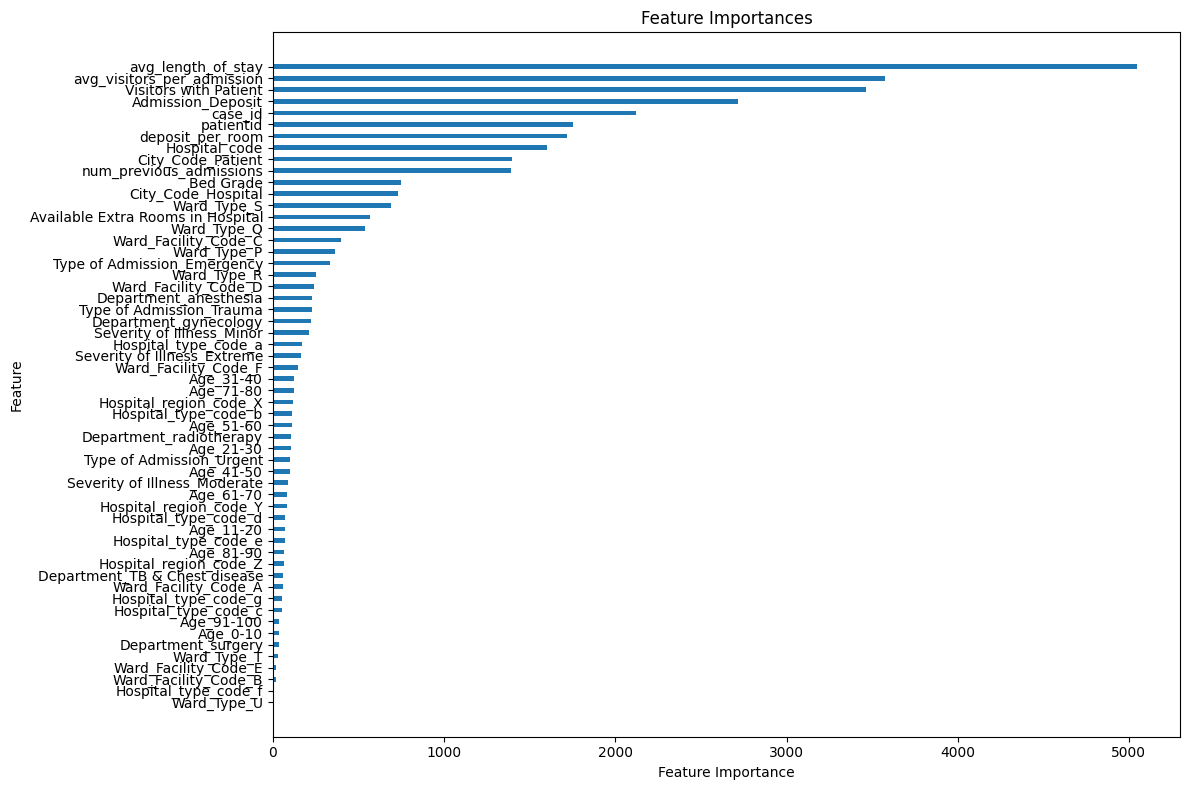

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Train the LightGBM model using all the features
model_lgbm_all_features = LGBMClassifier(random_state=42)
model_lgbm_all_features.fit(X_train_preprocessed, y_train_train)

# Get feature importances from the trained model
feature_importances = model_lgbm_all_features.feature_importances_

# Get feature names
feature_names = X_train_preprocessed.columns

# Sort features based on their importances
sorted_indices = np.argsort(feature_importances)[::-1]
sorted_features = [feature_names[idx] for idx in sorted_indices]
sorted_importances = feature_importances[sorted_indices]

# Plot the accuracy of the model for each feature
plt.figure(figsize=(12, 8))
bar_positions = np.arange(len(sorted_features)) * 2
plt.barh(bar_positions, sorted_importances, align='center')
plt.yticks(bar_positions, sorted_features)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()  # Adjust layout to prevent overlapping labels
plt.show()


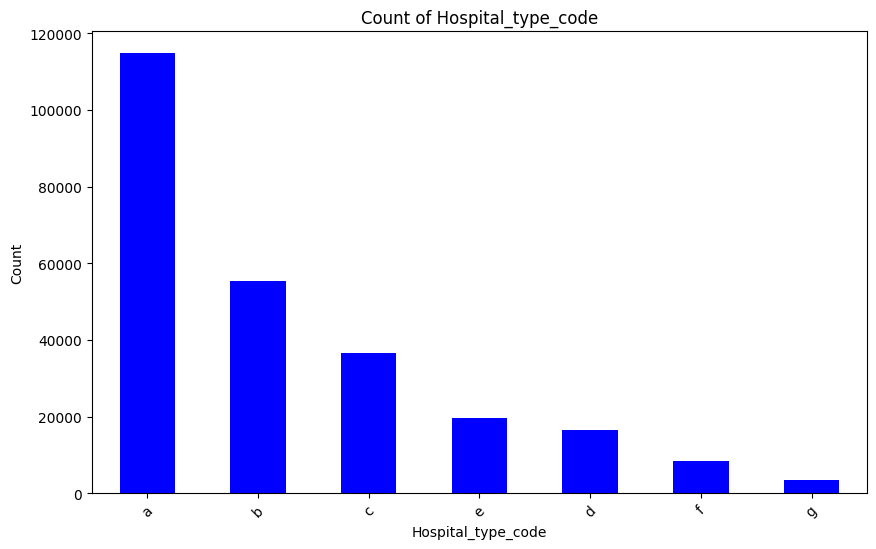

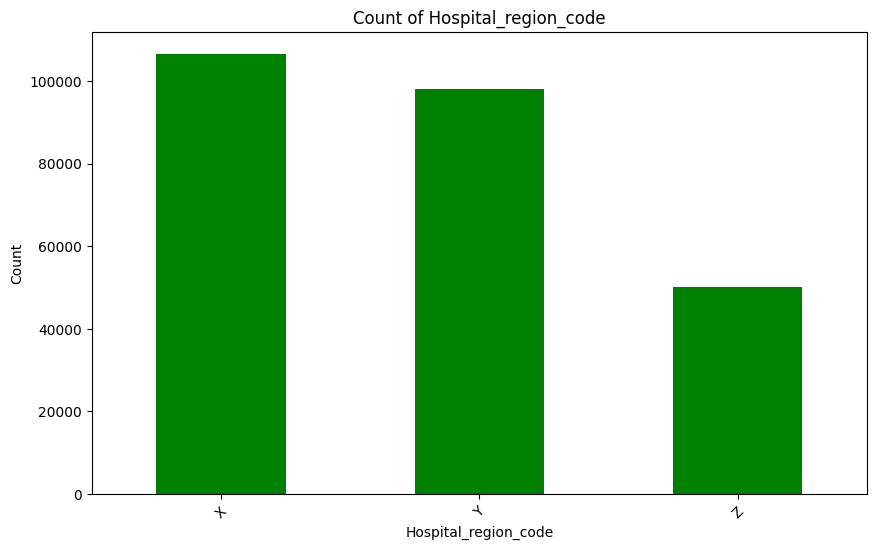

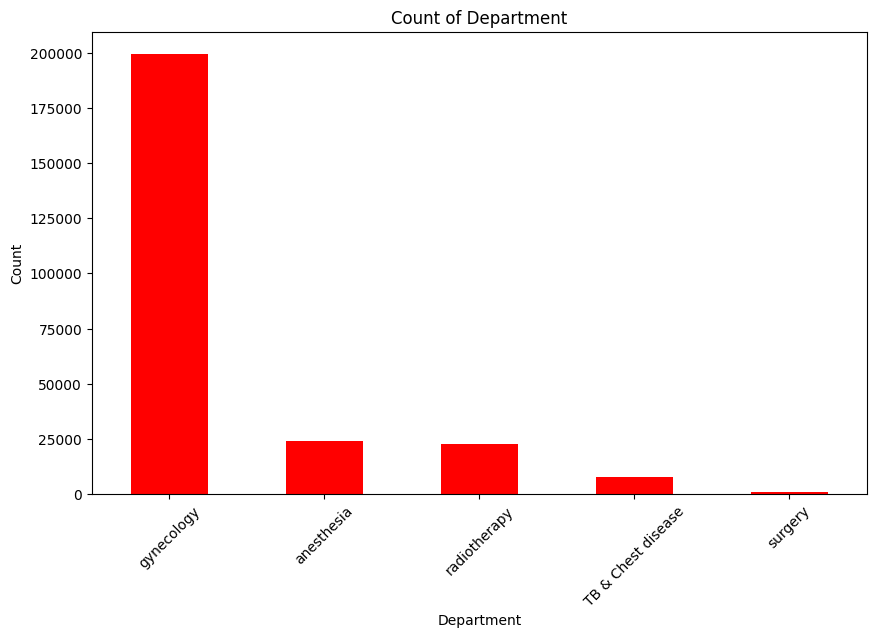

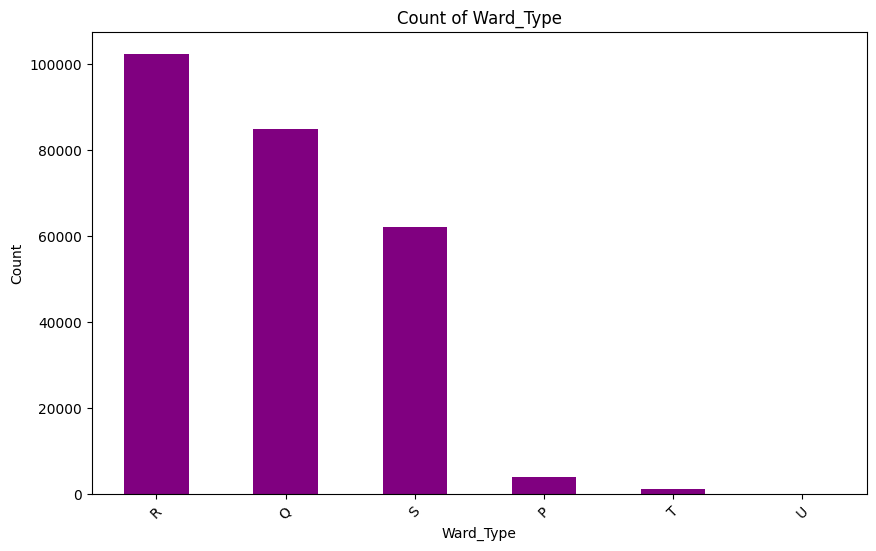

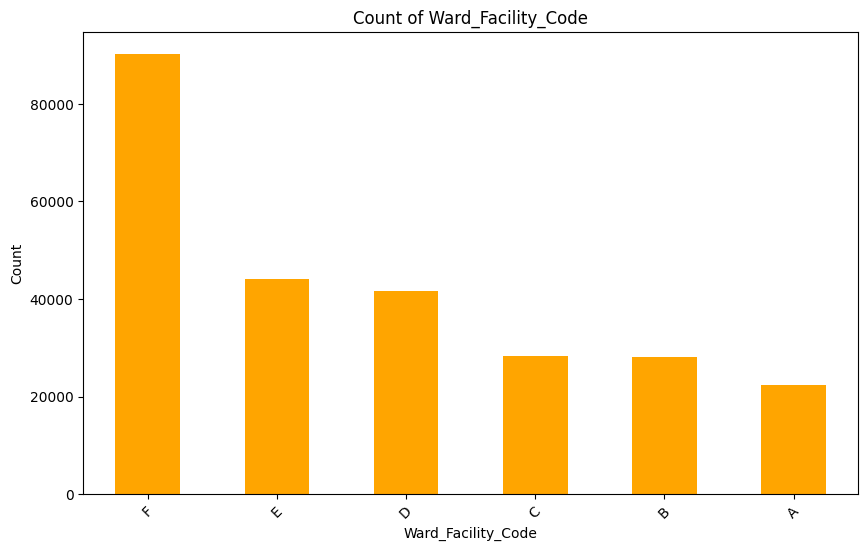

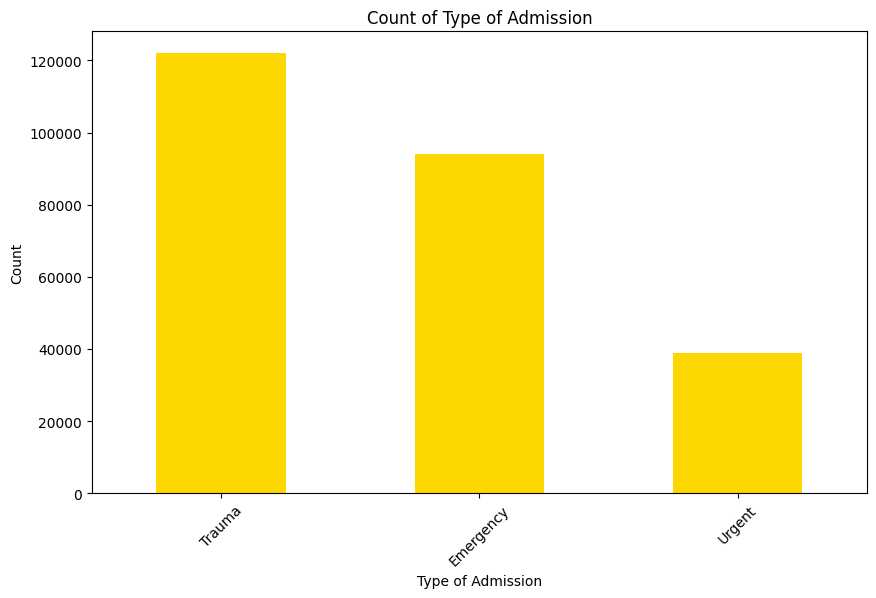

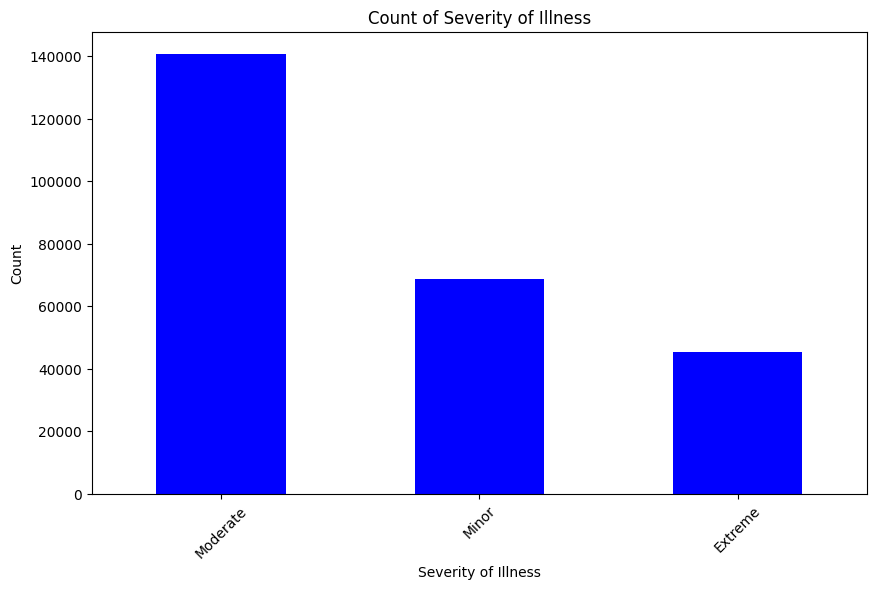

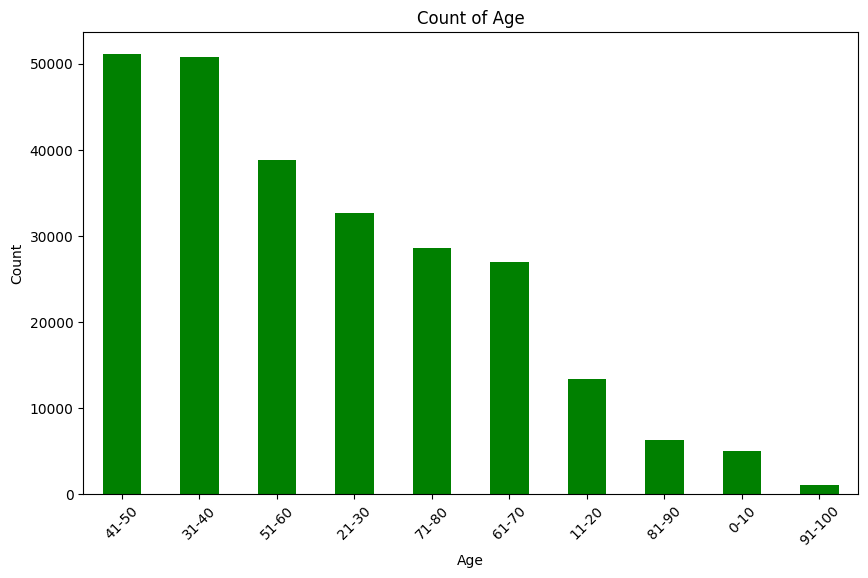

In [4]:
import matplotlib.pyplot as plt

# Define colors for the bars
bar_colors = ['blue', 'green', 'red', 'purple', 'orange', 'gold', 'blue', 'green']

# Loop through each feature
for i, feature in enumerate(['Hospital_type_code', 'Hospital_region_code', 'Department', 'Ward_Type', 
                'Ward_Facility_Code', 'Type of Admission', 'Severity of Illness', 'Age']):

    # Plot bar chart for the feature
    plt.figure(figsize=(10, 6))
    X_train_train[feature].value_counts().plot(kind='bar', color=bar_colors[i])
    plt.title(f'Count of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


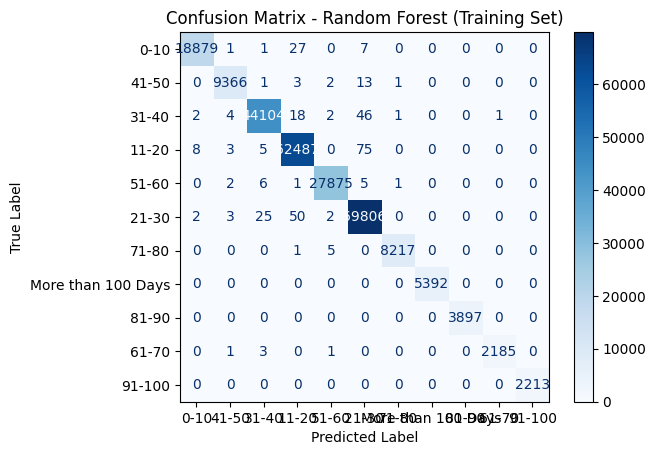

C:\Users\Sai Konatham\AppData\Local\Temp\ipykernel_26116\1598038683.py:18: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df_train.corr()


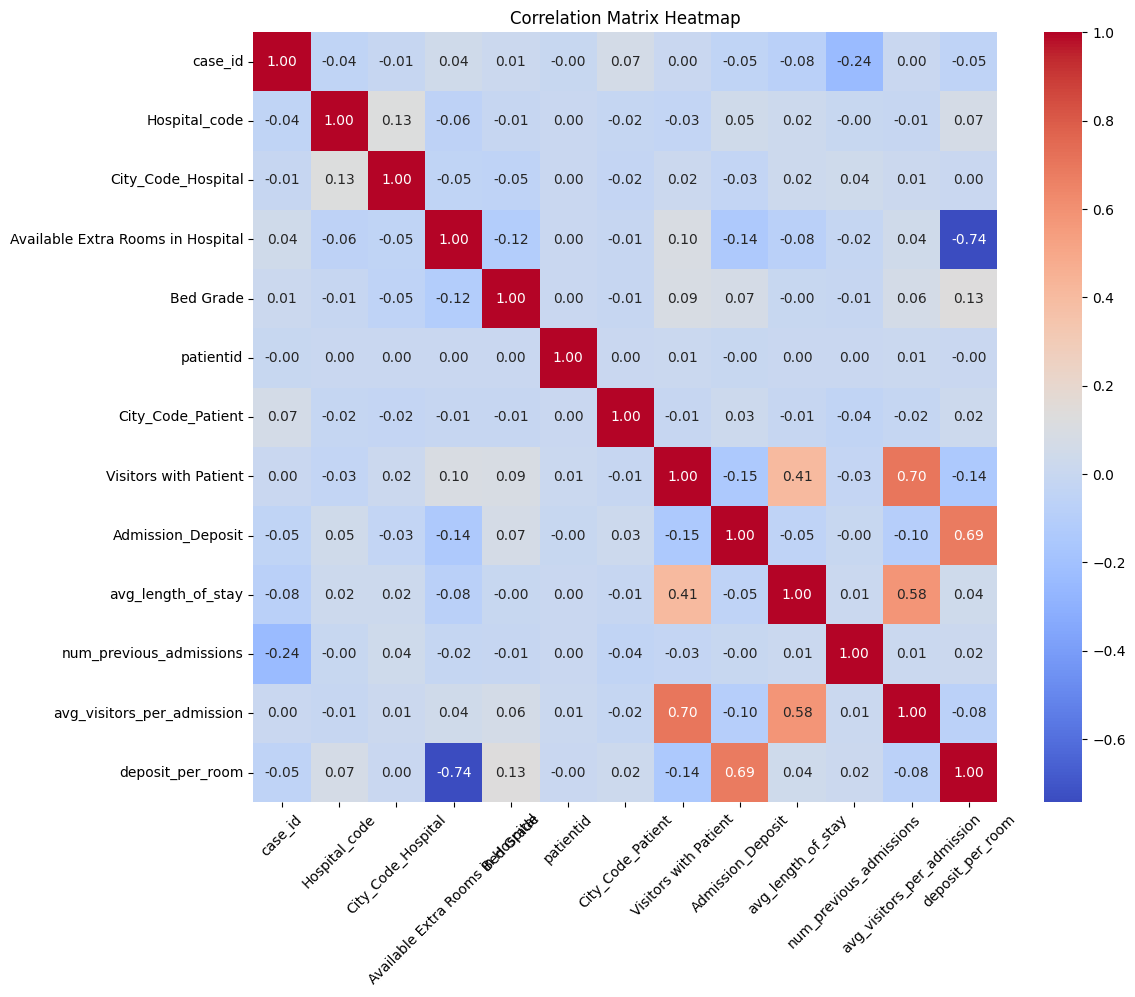

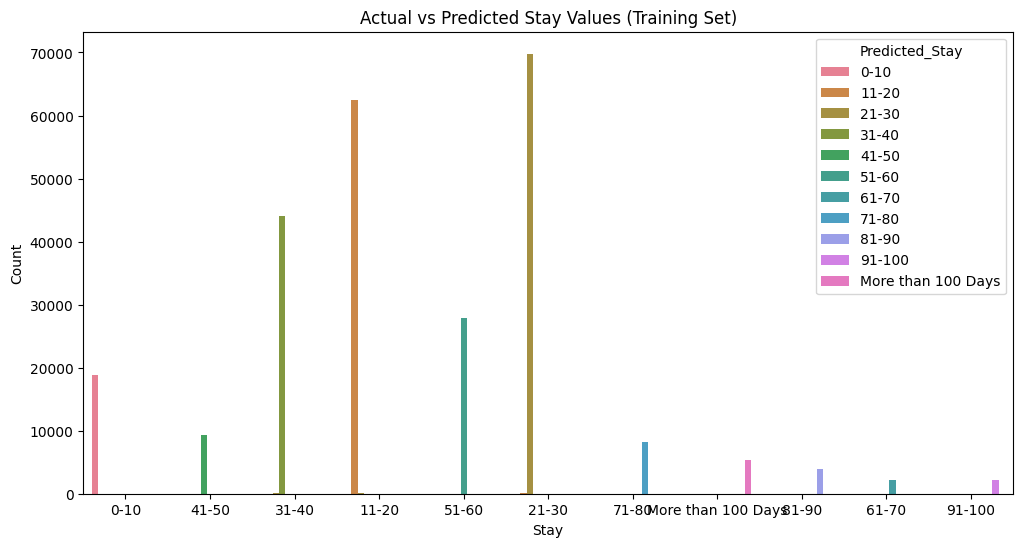

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Random Forest on Training Set
predictions_train_rf = model_rf.predict(X_train_selected)
cm_rf = confusion_matrix(y_train_train, predictions_train_rf, labels=df_train['Stay'].unique())

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=df_train['Stay'].unique())
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest (Training Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Compute correlation matrix
correlation_matrix = df_train.corr()

# Plot correlation matrix heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Bar Chart - Actual vs Predicted Stay Values
results_df['Actual_Stay'] = results_df['Actual_Stay'].astype('category')
results_df['Predicted_Stay'] = results_df['Predicted_Stay'].astype('category')

# Define the order of categories for better visualization
stay_order = df_train['Stay'].unique()

plt.figure(figsize=(12, 6))
sns.countplot(data=results_df, x='Actual_Stay', hue='Predicted_Stay', order=stay_order)
plt.title('Actual vs Predicted Stay Values (Training Set)')
plt.xlabel('Stay')
plt.ylabel('Count')
plt.show()
